In [1]:
!uv add Pillow

Resolved 2 packages in 1ms
Audited 1 package in 0.07ms


In [49]:

from typing import Optional, Tuple
from math import log
from PIL import Image, ImageDraw, ImageFont
from dataclasses import dataclass
from IPython.display import HTML

In [3]:
def font_measure(font):
    _, extended_font_measure_top, _, extended_font_measure_bottom = text_font.getbbox("Hg")
    _, small_font_measure_top, _, small_font_measure_bottom = text_font.getbbox("ao")
    print(extended_font_measure_top,extended_font_measure_bottom,small_font_measure_top, small_font_measure_bottom)

In [4]:
def textbox_bounds(xy, text, font):
    x,y=xy
    fm_ascent, fm_descent = font.getmetrics()
    font_measure_width = font.getlength(text)
    return (x, y-fm_ascent, x+font_measure_width, y+fm_descent)

In [39]:

def scorechar(c, loc, target, bchars):
    score=0
    adj=1/target
    neg=0
    if c in bchars:
        if loc>target:
            neg=((loc-target)**3)
        score = 1 / ((( loc-target) **2 ) + 1 + neg)
    else:
        score = 1 / ((( loc-target) **2 ) + 1) *(adj**2)
    return score


def word_wrap(text, target_length):
    linespace = 1.2
    breakchars = " ,.-"
    delchars = "\t"
    for c in delchars:
        text = text.replace(c," ")
    best_split = 0
    texts = []
    finished=False
    stext = "".join([t for t in text])
    while not finished and len(stext)!=0:
        osp = [scorechar(c,e,target_length, breakchars) for e,c in enumerate(stext)]
        best_split = osp.index(max(osp))

        if len(stext)==0 or best_split==0 or (target_length*linespace)>=len(stext):
            texts.append(stext)
            finished=True
        else:
            texts.append(stext[:best_split+1])
        stext = stext[best_split+1:]
    return texts


class TextMultiLine:

    def __init__(self, 
                 pos : tuple[int, int],
                 text : str,
                 linespace : int,
                 font : ImageFont):
        self.pos=pos
        self.text=text
        self.font=font

        sample_t = TextLine(pos, "Hg", font)

        self.text_lines = [TextLine((pos[0],pos[1]+(sample_t.lineheight*e*linespace)), 
                          t, 
                          font) for e,t in enumerate(text.split("\n"))]

    def _bounds(self):
        all_bounds = [tl._bounds() for tl in self.text_lines]
        x0,y0=min([b[0] for b in all_bounds]), min([b[1] for b in all_bounds])
        x1,y1=max([b[2] for b in all_bounds]), max([b[3] for b in all_bounds])
        return x0,y0,x1,y1
    
    def _pillow_draw(self, drawing_object, **kwargs):
            
        if 'block' in kwargs.keys():
            print("block!")
            bounds=self._bounds()
            print(bounds)
            drawing_object.rectangle(
                [*bounds],
                outline=bbox_color_f,
                width=1,
                fill=kwargs['block']
            )
        
        for tl in self.text_lines:
            tl._pillow_draw(drawing_object, **kwargs)


class TextLine:
    
    def __init__(self, 
                 pos : tuple[int, int],
                 text : str,
                 font : ImageFont):
        self.pos=pos
        self.text=text
        self.font=font
        _, top, _, bottom = self._bounds()
        self.lineheight = bottom - top

    def _bounds(self):
        x,y=self.pos
        fm_ascent, fm_descent = self.font.getmetrics()
        font_measure_width = self.font.getlength(self.text)
        return (x, y-fm_ascent, x+font_measure_width, y+fm_descent)

    def _pillow_draw(self, drawing_object, **kwargs):
        if 'anchor' not in kwargs.keys():
            kwargs['anchor']='ls'
        if 'fill' not in kwargs.keys():
            kwargs['fill']='black'
        x,y=self.pos
        bounds=self._bounds()
        if 'highlight' in kwargs.keys():
            drawing_object.rectangle(
                [*bounds],
                outline=bbox_color_f,
                width=1,
                fill=kwargs['highlight']
            )
        if 'baseline' in kwargs.keys():
            drawing_object.line([x, y,bounds[2], y],
                 fill=kwargs['baseline'], width=5)
        
        drawing_object.text((x,y), self.text, font=self.font, fill=kwargs['fill'], anchor=kwargs['anchor'])


class LayoutFrame:

    def __init__(self, 
                 width : int, 
                 height : int, 
                 padding : int, 
                 x_gridsize : int, 
                 y_gridsize : int, 
                 font : ImageFont):

        self.padding=padding
        self.width=width
        self.height=height
        self.x_gridsize=x_gridsize
        self.y_gridsize=y_gridsize
        self.cell_height=int(height/y_gridsize)
        self.cell_width=int(width/x_gridsize)
        self.font=font

    def _pillow_draw(self, drawing_object, **kwargs):
        # Draw padding rectangle
        drawing_object.rectangle(
            [0, 0, self.width+(2*self.padding), self.height+(2*self.padding)],
            outline="red",
            width=1,
        )
        #Draw horizontal gridlines
        for i in range(0,self.y_gridsize+1):
            y = i*self.cell_height
            drawing_object.text((self.padding, y+self.padding), str(y), font=self.font, fill=text_color, anchor='rm')
            drawing_object.line([(self.padding, y+self.padding), (self.padding + self.width, y+self.padding)], fill=axis_color, width=2)
            
        
        for i in range(0,self.x_gridsize+1):
            x = i*self.cell_width
            drawing_object.line([(x+self.padding, self.padding), (x+self.padding, self.padding+self.height)], fill=axis_color, width=2)
            drawing_object.text((x+self.padding, self.padding), str(x), font=self.font, fill=text_color, anchor='ms')


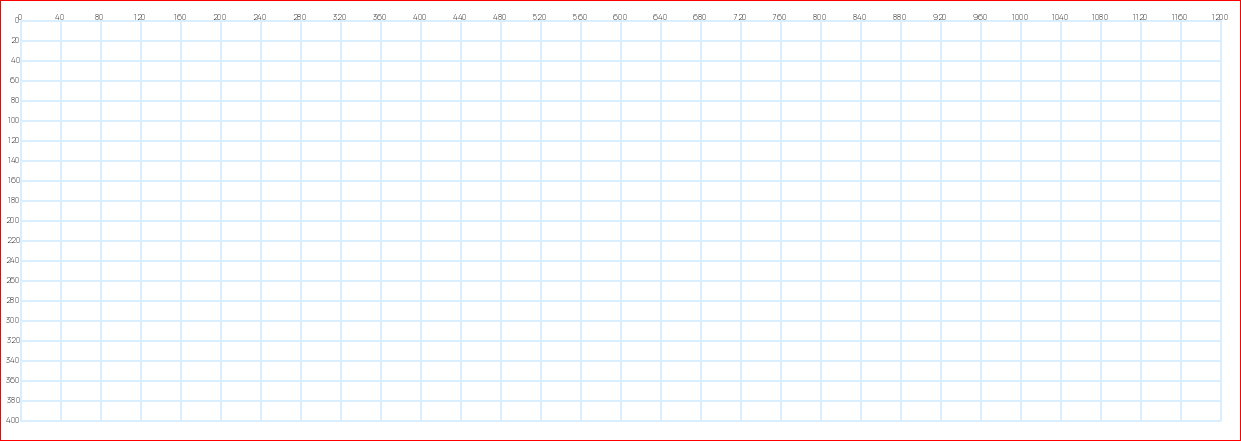

In [172]:
img_width=1200
img_height=400
bg_color = (255, 255, 255)
text_color = (0, 0, 0, 220)
axis_color = (80, 180, 255, 55)
bbox_color = (255, 0, 0, 105)
bbox_color_f = (255, 0, 255, 105)
image_padding = 20
img = Image.new("RGBA", (img_width+(2*image_padding)+1, img_height+(2*image_padding)+1), bg_color)
img = Image.new("RGBA", (img_width+(2*image_padding)+1, img_height+(2*image_padding)+1), bg_color)
draw = ImageDraw.Draw(img)
font_path = "DejaVuSans.ttf"
font_path = "Manrope-VariableFont_wght.ttf"
Comfortaa_font_path="Comfortaa-VariableFont_wght.ttf"
font_path = "Manrope-VariableFont_wght.ttf"
font_size = 8
text_font = ImageFont.truetype(font_path, 12)
alt_text_font = ImageFont.truetype(Comfortaa_font_path, 32)
x_axis_font = ImageFont.truetype(font_path, font_size)

lf = LayoutFrame(img_width, img_height,image_padding, 30,20, x_axis_font)
lf._pillow_draw(draw)

texts = ["ABCDEFGHIJKLMNOPQRSTUVWXYZ",
         "ace",
         "Hag",
         "The quick brown fox jumps over the lazy dog.",
         "Quick",
         "Flourishing",
         "Hungry"]


for i,t in enumerate(texts):
    x=80+image_padding
    y = ((i+1) * (lf.cell_height*2))+image_padding

    tl = TextLine((x,y), t, text_font)
    #tl._pillow_draw(draw, highlight='orange', baseline='cyan')
    bx0,by0,bx1,by1=tl._bounds()
    
    #draw.text((x+image_padding_x_y[0], y+image_padding_x_y[1]), t, font=text_font, fill=text_color, anchor='ls')
    #x0,y0,x1,y1 = textbox_bounds((x+image_padding_x_y[0],y+image_padding_x_y[1]), t, text_font)


    #draw.text((x+image_padding_x_y[0], y+image_padding_x_y[1]), t, font=alt_text_font, fill=text_color, anchor='ls')
img

In [173]:
text = """Mary had a little lamb
Its fleece as white as snow
And everywhere that Mary went
The lamb was sure to go"""

text="""Hofstadter was initially appointed to Indiana University's computer science department faculty in 1977, and at that time he launched his research program in computer modeling of mental processes (which he called "artificial intelligence research", a label he has since dropped in favor of "cognitive science research").
In 1984, he moved to the University of Michigan in Ann Arbor, where he was hired as a professor of psychology and was also appointed to the Walgreen Chair for the Study of Human Understanding."""

text="""Hofstadter's thesis about consciousness, first expressed in Gödel, Escher, Bach but also present in several of his later books, is that it is "an emergent consequence of seething lower-level activity in the brain."[citation needed] In Gödel, Escher, Bach he draws an analogy between the social organization of a colony of ants and the mind seen as a coherent "colony" of neurons. In particular, Hofstadter claims that our sense of having (or being) an "I" comes from the abstract pattern he terms a "strange loop", an abstract cousin of such concrete phenomena as audio and video feedback that Hofstadter has defined as "a level-crossing feedback loop". The prototypical example of a strange loop is the self-referential structure at the core of Gödel's incompleteness theorems. Hofstadter's 2007 book I Am a Strange Loop carries his vision of consciousness considerably further, including the idea that each human "I" is distributed over numerous brains, rather than being limited to one."""

In [199]:
def word_wrap(line, target, bchars):
    
    linebreaks=[]
    lines=[]
    progress=0
    while len(line.strip())>0:
        scores={}
        for e,c in enumerate(line):
            progress=e
            if c in bchars:
                adj=1
            else:
                adj=0
            if e<target:
                scores[e]=log(e+1)+adj
            else:
                scores[e]=0
                break
        if scores[e]==0:
            best=sorted([(k,v) for k,v in scores.items()], key=lambda x:x[1], reverse=True)[0]
            print(best, progress)
        else:
            best=[len(line),0]
        linebreaks.append(best[0])
        lines.append(line[:best[0]])
        line=line[best[0]:]
    return lines
        
ww_text = []
ww_lines = text.split("\n")
for line in ww_lines:
    ww_text.extend(word_wrap(line, 50, " "))
ww_text

(46, 4.850147601710058) 50
(42, 4.761200115693562) 50
(47, 4.871201010907891) 50
(43, 4.7841896339182615) 50
(45, 4.828641396489095) 50
(43, 4.7841896339182615) 50
(45, 4.828641396489095) 50
(47, 4.871201010907891) 50
(47, 4.871201010907891) 50
(46, 4.850147601710058) 50
(47, 4.871201010907891) 50
(43, 4.7841896339182615) 50
(47, 4.871201010907891) 50
(49, 4.912023005428146) 50
(46, 4.850147601710058) 50
(47, 4.871201010907891) 50
(48, 4.891820298110627) 50
(43, 4.7841896339182615) 50
(49, 4.912023005428146) 50
(48, 4.891820298110627) 50
(49, 4.912023005428146) 50


["Hofstadter's thesis about consciousness, first",
 ' expressed in Gödel, Escher, Bach but also',
 ' present in several of his later books, is that',
 ' it is "an emergent consequence of seething',
 ' lower-level activity in the brain."[citation',
 ' needed] In Gödel, Escher, Bach he draws an',
 ' analogy between the social organization of a',
 ' colony of ants and the mind seen as a coherent',
 ' "colony" of neurons. In particular, Hofstadter',
 ' claims that our sense of having (or being) an',
 ' "I" comes from the abstract pattern he terms a',
 ' "strange loop", an abstract cousin of such',
 ' concrete phenomena as audio and video feedback',
 ' that Hofstadter has defined as "a level-crossing',
 ' feedback loop". The prototypical example of a',
 ' strange loop is the self-referential structure',
 " at the core of Gödel's incompleteness theorems.",
 " Hofstadter's 2007 book I Am a Strange Loop",
 ' carries his vision of consciousness considerably',
 ' further, including the idea that

In [200]:
ww_text="\n".join([l.strip() for l in ww_text])

block!
(20, 47.0, 288.359375, 421.0)


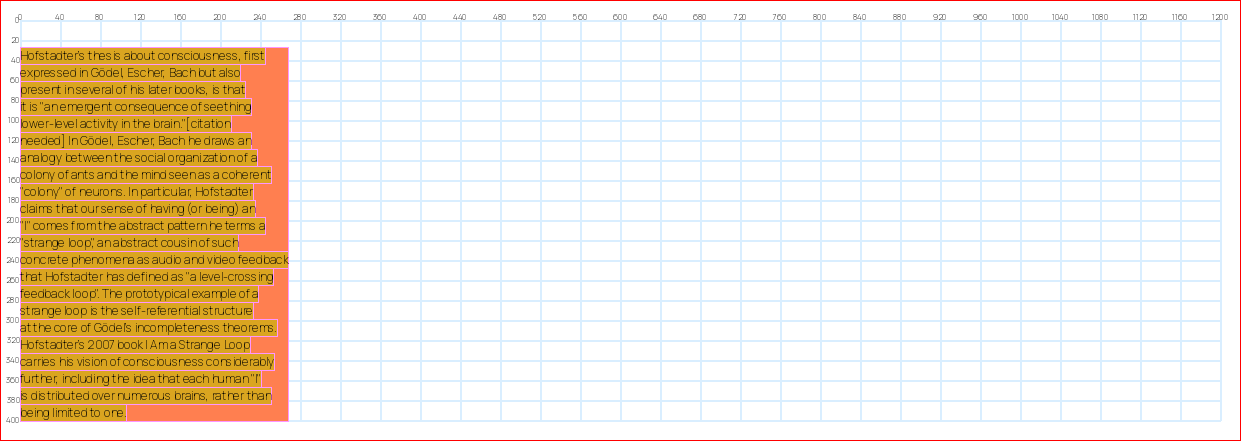

In [201]:
img = Image.new("RGBA", (img_width+(2*image_padding)+1, img_height+(2*image_padding)+1), bg_color)
draw = ImageDraw.Draw(img)

lf = LayoutFrame(img_width, img_height,image_padding, 30,20, x_axis_font)
lf._pillow_draw(draw)

mary_t = TextMultiLine((0+image_padding,40+image_padding), ww_text, 1.0, text_font)
mary_t._pillow_draw(draw, highlight='goldenrod', block='coral')
img

In [ ]:
assert False

In [ ]:
@dataclass
class TextLayout:
    lines: list[str]
    width: float
    height: float
    line_height: float
    ascent: float
    descent: float


def layout_text(
    text: str,
    font: ImageFont.FreeTypeFont,
    max_width: Optional[float] = None,
    line_height_scale: float = 1.2,
) -> TextLayout:
    if max_width is not None and max_width <= 0:
        raise ValueError("max_width must be positive when specified")

    raw_lines = text.split("\n")

    if max_width is None:
        out_lines = raw_lines
    else:
        out_lines = []
        for raw in raw_lines:
            out_lines.extend(_wrap_line(raw, font, max_width))

    line_widths = [font.getlength(line) for line in out_lines]
    width = max(line_widths) if line_widths else 0.0

    left, top, right, bottom = font.getbbox("Hg") # Use Hg to access the highest and lowest letters
    ascent = -top
    descent = bottom
    line_height = (ascent + descent) * line_height_scale

    height = len(out_lines) * line_height

    return TextLayout(
        lines=out_lines,
        width=width,
        height=height,
        line_height=line_height,
        ascent=ascent,
        descent=descent,
    )

def _wrap_line(line: str, font: ImageFont.FreeTypeFont, max_width: float) -> list[str]:
    if not line:
        return [""]

    words = line.split()
    result: list[str] = []
    current = ""

    for w in words:
        test = (current + " " + w) if current else w
        if font.getlength(test) <= max_width:
            current = test
        else:
            if current:
                result.append(current)
            current = w

    if current:
        result.append(current)

    return result or [""]

def render_text_preview(
    text: str,
    font: ImageFont.FreeTypeFont,
    max_width: Optional[float] = None,
    line_height_scale: float = 1.2,
    padding: float = 20.0,
    bg_color: Tuple[int, int, int] = (255, 255, 255),
    text_color: Tuple[int, int, int] = (0, 0, 0),
) -> Image.Image:
    """
    Render the laid-out text to a Pillow image for visual inspection.

    Returns a PIL.Image (RGB) that you can:
      - save: img.save("preview.png")
      - show: img.show()
      - display in a notebook: display(img)
    """
    layout = layout_text(text, font, max_width, line_height_scale)

    # Compute image size: include padding around the text block
    img_width = int(layout.width + 2 * padding)
    img_height = int(layout.height + 2 * padding)

    img = Image.new("RGB", (img_width, img_height), bg_color)
    draw = ImageDraw.Draw(img)

    # Top-left of text block inside the image
    origin_x = padding
    origin_y = padding

    # Place first baseline at origin_y + ascent
    y = origin_y + layout.ascent

    for i, line in enumerate(layout.lines):
        draw.text((origin_x, y), line, font=font, fill=text_color, anchor="lb")
        y += layout.line_height

    return img

In [ ]:
font_path = "DejaVuSans.ttf"
font_size = 14
font = ImageFont.truetype(font_path, font_size)
text = "Mary had a little lamb"
render_text_preview(text, font)

In [ ]:
layout = layout_text(text, font, max_width=200, line_height_scale=1.6)

In [ ]:
width, height = 300, 150
img = Image.new("RGB", (width, height), "white")
draw = ImageDraw.Draw(img)

x0, y0 = 20, 20  # top-left of text block

# Draw the text
y = y0 + layout.ascent
for line in layout.lines:
    draw.text((x0, y), line, font=font, fill="black", anchor='ls')
    y += layout.line_height

# Draw a rectangle that should tightly enclose the text block:
#   top-left: (x0, y0)
#   width: layout.width
#   height: layout.height
rect_x0 = x0
rect_y0 = y0
rect_w = layout.width
rect_h = layout.height

# Use outline only
draw.rectangle(
    [rect_x0, rect_y0, rect_x0 + rect_w, rect_y0 + rect_h],
    outline="red",
    width=1,
)

# Optionally, draw the baseline of the first line:
baseline_y = y0 + layout.descent
draw.line([(x0, baseline_y), (x0 + rect_w, baseline_y)], fill="blue", width=1)

In [ ]:
img

In [ ]:
layout